# <font color='dark'>**Detecção de texto em placas de carro**</h1>

# <font color='dark'>**Aula 1**</h1>

### Instalação do tesseract

Necessário instalar o tesseract na máquina. Como o Colab utiliza um computador com sistema operacional Linux, é preciso utilizar o comando `!sudo apt install tesseract-ocr`.

Informação disponível na [documentação do tesseract](https://tesseract-ocr.github.io/tessdoc/Installation.html)

Na mesma documentação é possível ver as linguagens disponíveis no [github](https://github.com/tesseract-ocr/tessdata). Para utilizar a língua portuguesa, precisamos usar o arquivo `por.tessdata`

Para usar o tesseract com a linguagem python, devemos instalar o pacote `pytesseract`, disponível no [PyPI](https://pypi.org/project/pytesseract/).

Podemos baixar diretamente o arquivo `por.tessdata` do [github](https://github.com/tesseract-ocr/tessdata) ou baixar diretamente para o Google Colab com o comando `wget`.

### Importação das bibliotecas

In [1]:
import cv2
import pytesseract

In [2]:
cv2.__version__

'4.11.0'

In [3]:
pytesseract.__version__

'0.3.13'

### Leitura da imagem

In [4]:
imagem = cv2.imread('images/trecho_livro.png')

In [5]:
texto = pytesseract.image_to_string(imagem)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente 0 bry.
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... A
porgdes sao convencionadas e as fronteiras, imprecisas.
um santo eremita e nao pratiquei apenas 0 bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro

abster-me por completo da escolha. Esta na hora de ir embora.
Ver-nos-emos amanha.

S Dro-

40 SOU




In [6]:
!tesseract --help-psm

Page segmentation modes (PSM):
  0|osd_only                Orientation and script detection (OSD) only.
  1|auto_osd                Automatic page segmentation with OSD.
  2|auto_only               Automatic page segmentation, but no OSD, or OCR. (not implemented)
  3|auto                    Fully automatic page segmentation, but no OSD. (Default)
  4|single_column           Assume a single column of text of variable sizes.
  5|single_block_vert_text  Assume a single uniform block of vertically aligned text.
  6|single_block            Assume a single uniform block of text.
  7|single_line             Treat the image as a single text line.
  8|single_word             Treat the image as a single word.
  9|circle_word             Treat the image as a single word in a circle.
 10|single_char             Treat the image as a single character.
 11|sparse_text             Sparse text. Find as much text as possible in no particular order.
 12|sparse_text_osd         Sparse text with OSD.
 13|

In [7]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
texto = pytesseract.image_to_string(imagem, lang = 'por', config = config_tesseract)
print(texto)

— Um mal é um mal, Stregobor — retrucou seriamente o bry-
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... As pro-
porções são convencionadas e as fronteiras, imprecisas. Não sou
um santo eremita e não pratiquei apenas o bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro
abster-me por completo da escolha. Está na hora de ir embora. |
Ver-nos-emos amanhã. |



In [8]:
imagem = cv2.imread('images/placa_carro1.png')

A biblioteca opencv importa as imagens com os canais BGR, como pode ser visto na [documentação](https://docs.opencv.org/3.4/d4/da8/group__imgcodecs.html)

> **Note**

> *In the case of color images, the decoded images will have the channels stored in B G R order.*

O tesseract entende os canais na ordem RGB, portanto devemos fazer uma conversão da imagem de BGR para GRAY(escala de cinza), com o uso da função `cv2.cvtColor()`

In [9]:
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

In [11]:
config_tesseract = '--tessdata-dir ../tessdata'
texto = pytesseract.image_to_string(imagem, lang = 'por', config = config_tesseract)
print(texto)

# <font color='dark'>**Aula 2**</h1>

Para conseguir realizar melhor a detecção dos textos contidos na imagem, podemos aplicar pré-processamentos na imagem a fim de deixar os caracteres mais destacados do restante da imagem.

Um desses pré-processamentos é a limiarização, que consiste em transformar a imagem totalmente para preto e branco.

- [Documentação OpenCV: Limiarização](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)

### Limiarização simples

![](https://i.imgur.com/9diya8F.gif)

In [12]:
limiar = 25
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)

In [13]:
limiar = 127
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)

In [14]:
limiar = 170
valor, lim_simples = cv2.threshold(imagem, limiar, 255, cv2.THRESH_BINARY)

### Limiarização adaptativa

![](https://i.imgur.com/j6w6Rwu.gif)

In [15]:
lim_adapt = cv2.adaptiveThreshold(imagem, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)

In [16]:
lim_adapt = cv2.adaptiveThreshold(imagem, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 8)

### Limiarização de Otsu

Podemos ver a intensidade de cor de uma imagem através de histogramas. A documentação do opencv sugere algumas formas de criar histogramas a partir de imagens:

- [Documentação OpenCV: Histogramas](https://docs.opencv.org/4.x/d1/db7/tutorial_py_histogram_begins.html)

In [17]:
imagem

array([[ 14,  14,   2, ...,   5,   5,   5],
       [ 14,  14,   2, ...,   5,   5,   5],
       [ 14,  14,   3, ...,   5,   5,   5],
       ...,
       [ 14,  14, 144, ..., 122, 121, 120],
       [ 14,  14,  14, ...,  14,  14,  14],
       [ 14,  14,  14, ...,  14,  14,  14]], dtype=uint8)

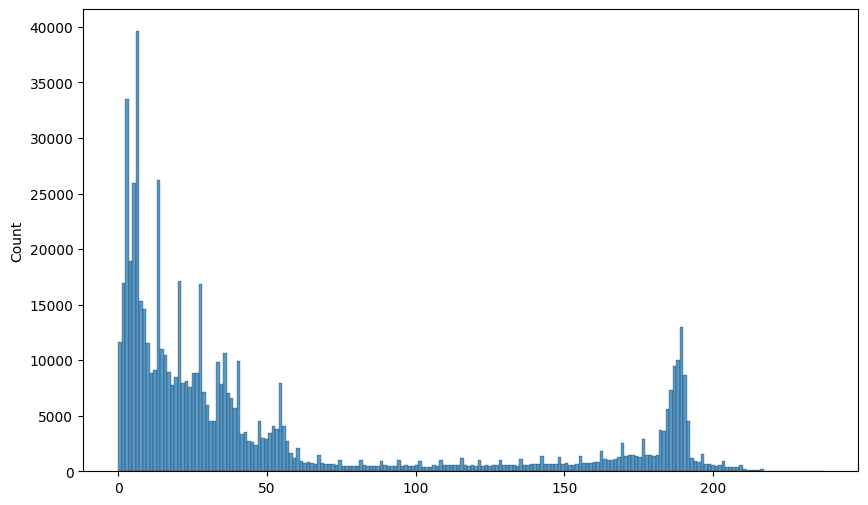

In [18]:
import seaborn as sns
ax = sns.histplot(imagem.flatten())
ax.figure.set_size_inches(10,6)

In [19]:
valor, lim_otsu = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
print(f'Limiar: {valor}')

Limiar: 96.0


In [21]:
config_tesseract = '--tessdata-dir ../tessdata'
texto = pytesseract.image_to_string(lim_otsu, lang = 'por', config = config_tesseract)
print(texto)

# <font color='dark'>**Aula 3**</h1>

É possível aplicar transformações na figura de forma a expandir, reduzir ou modificar a estrutura dos pixels da imagem a partir de um Kernel. São chamadas de transformações morfológicas.

As transformações morfológicas básicas são erosão e dilatação.

A partir delas são construídas as transformações de abertura, fechamento, gradiente, top hat (cartola) e black hat (chapéu preto).

- [Documentação OpenCV: Transformações Morfológicas](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)

In [22]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

In [23]:
erosao = cv2.erode(lim_otsu,kernel)

In [24]:
dilatacao = cv2.dilate(lim_otsu,kernel)

In [25]:
abertura = cv2.morphologyEx(lim_otsu, cv2.MORPH_OPEN, kernel)

In [26]:
fechamento = cv2.morphologyEx(lim_otsu, cv2.MORPH_CLOSE, kernel)

In [27]:
gradiente = cv2.morphologyEx(lim_otsu, cv2.MORPH_GRADIENT, kernel)

In [28]:
cartola = cv2.morphologyEx(lim_otsu, cv2.MORPH_TOPHAT, kernel)

In [29]:
kernel_retangular = cv2.getStructuringElement(cv2.MORPH_RECT, (40,13))
cartola = cv2.morphologyEx(lim_otsu, cv2.MORPH_TOPHAT, kernel_retangular)

In [30]:
cartola = cv2.morphologyEx(imagem, cv2.MORPH_TOPHAT, kernel_retangular)

In [31]:
chapeu_preto = cv2.morphologyEx(lim_otsu, cv2.MORPH_BLACKHAT, kernel_retangular)

In [32]:
chapeu_preto = cv2.morphologyEx(imagem, cv2.MORPH_BLACKHAT, kernel_retangular)

In [33]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
texto = pytesseract.image_to_string(erosao, lang = 'por', config = config_tesseract)
print(texto)

, PLRÓD97 |
R .S %



# <font color='dark'>**Aula 4**</h1>

Podemos detectar as bordas das imagens com o uso do método `Canny()`, através das bordas é possível encontrar a localização da placa, através dos contornos fechados em forma retangular.

- [Documentação OpenCV: Detector de bordas de Canny](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html)

In [34]:
bordas = cv2.Canny(imagem, 100, 200)

Para detectar os contornos das placas, podemos usar o método `findContours()`.

- [Documentação OpenCV: Contornos](https://docs.opencv.org/4.x/d3/d05/tutorial_py_table_of_contents_contours.html)

In [35]:
contornos, hierarquia = cv2.findContours(bordas, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [36]:
contornos

(array([[[1069,  593]],
 
        [[1068,  594]],
 
        [[1057,  594]],
 
        [[1056,  595]],
 
        [[1045,  595]],
 
        [[1044,  596]],
 
        [[1018,  596]],
 
        [[1044,  596]],
 
        [[1045,  595]],
 
        [[1056,  595]],
 
        [[1057,  594]],
 
        [[1068,  594]],
 
        [[1069,  593]],
 
        [[1082,  593]]], dtype=int32),
 array([[[490, 571]],
 
        [[489, 572]],
 
        [[490, 571]],
 
        [[517, 571]],
 
        [[518, 572]],
 
        [[519, 572]],
 
        [[520, 571]],
 
        [[548, 571]],
 
        [[549, 572]],
 
        [[553, 572]],
 
        [[554, 571]],
 
        [[565, 571]],
 
        [[566, 572]],
 
        [[568, 572]],
 
        [[569, 571]],
 
        [[570, 572]],
 
        [[572, 572]],
 
        [[573, 571]],
 
        [[576, 571]],
 
        [[577, 572]],
 
        [[587, 572]],
 
        [[588, 571]],
 
        [[590, 571]],
 
        [[591, 572]],
 
        [[601, 572]],
 
        [[602, 571]],
 

In [37]:
for contorno in contornos:
    epsilon = 0.02 * cv2.arcLength(contorno, True)
    aproximacao = cv2.approxPolyDP(contorno, epsilon, True)
    if cv2.isContourConvex(aproximacao) and len(aproximacao) == 4:
        localizacao = aproximacao
        break

In [38]:
localizacao

array([[[180, 178]],

       [[196, 391]],

       [[901, 375]],

       [[894, 168]]], dtype=int32)

In [39]:
x, y, w, h = cv2.boundingRect(localizacao)

In [40]:
x

180

In [41]:
y

168

In [42]:
w

722

In [43]:
h

224

In [44]:
placa = imagem[y:y+h, x:x+w]

In [45]:
valor, lim_otsu = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
erosao = cv2.erode(lim_otsu, cv2.getStructuringElement(cv2.MORPH_RECT, (4,4)))

In [46]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
texto = pytesseract.image_to_string(erosao, lang = 'por', config = config_tesseract)
print(texto)

In [47]:
import re
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
texto_extraido

In [49]:
# print(texto_extraido.group(0))

### Aplicação em outro cenário

In [50]:
imagem = cv2.imread('images/placa_carro2.jpg')
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

In [51]:
bordas = cv2.Canny(imagem, 100, 200)

In [52]:
contornos, hierarquia = cv2.findContours(bordas, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key = cv2.contourArea, reverse=True)[:10]

In [53]:
for contorno in contornos:
    epsilon = 0.02 * cv2.arcLength(contorno, True)
    aproximacao = cv2.approxPolyDP(contorno, epsilon, True)
    if cv2.isContourConvex(aproximacao) and len(aproximacao) == 4:
        localizacao = aproximacao
        break

In [54]:
localizacao

array([[[1659,  737]],

       [[1656,  835]],

       [[1260,  850]],

       [[1259,  756]]], dtype=int32)

In [55]:
x, y, w, h = cv2.boundingRect(localizacao)

In [56]:
placa = imagem[y:y+h, x:x+w]

In [57]:
valor, lim_otsu = cv2.threshold(placa, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

In [58]:
texto = pytesseract.image_to_string(lim_otsu, lang = 'por', config = config_tesseract)
print(texto)

“POX4G21



In [59]:
texto_extraido = re.search('\w{3}\d{1}\w{1}\d{2}', texto)
texto_extraido

<re.Match object; span=(1, 8), match='POX4G21'>

In [60]:
print(texto_extraido.group(0))

POX4G21
